In [12]:
import pandas as pd

# Cargar dataset
df = pd.read_csv('../data/Precios_Casas_Boston.csv')

# Vista rápida
df.head()


,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0.0,538.0,6575.0,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0.0,469.0,6421.0,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0.0,458.0,6998.0,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0.0,458.0,7147.0,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,NaN
4,7,0.08829,12.5,7.87,0.0,524.0,6012.0,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9


In [13]:
df = df.drop(df.columns[[0]], axis=1)
display(df.head())

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.0,538.0,6575.0,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,469.0,6421.0,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.03237,0.0,2.18,0.0,458.0,6998.0,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0.0,458.0,7147.0,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,NaN
4,0.08829,12.5,7.87,0.0,524.0,6012.0,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9


In [14]:
for col in ['chas']:
    df[col] = df[col].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   crim     443 non-null    float64 
 1   zn       446 non-null    float64 
 2   indus    442 non-null    float64 
 3   chas     446 non-null    category
 4   nox      444 non-null    float64 
 5   rm       442 non-null    float64 
 6   age      444 non-null    float64 
 7   dis      442 non-null    float64 
 8   rad      444 non-null    float64 
 9   tax      443 non-null    float64 
 10  ptratio  446 non-null    float64 
 11  black    445 non-null    float64 
 12  lstat    447 non-null    float64 
 13  medv     432 non-null    float64 
dtypes: category(1), float64(13)
memory usage: 46.2 KB


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
crim,443.0,75.806953,894.067182,0.00632,0.09378,0.35233,4.548895,15288.00
zn,446.0,9.149103,20.794410,0.00000,0.00000,0.00000,0.000000,100.00
indus,442.0,12.032986,7.074594,0.74000,5.86000,10.01000,18.100000,27.74
nox,444.0,479.452313,227.804740,0.40000,433.00000,532.00000,614.000000,871.00
rm,442.0,5590.948077,1991.240670,4.97000,5710.00000,6098.50000,6437.750000,8725.00
age,444.0,71.260135,27.671128,6.00000,50.67500,82.15000,95.000000,100.00
dis,442.0,352.520877,1165.055292,1.12960,2.01620,3.09925,5.499950,8344.00
rad,444.0,9.801802,8.798543,1.00000,4.00000,5.00000,24.000000,24.00
tax,443.0,418.356659,171.611273,188.00000,284.50000,384.00000,666.000000,711.00
ptratio,446.0,18.400897,2.242069,12.60000,16.80000,19.00000,20.200000,21.20


In [16]:
#pip install ydata-profiling

In [17]:
#from ydata_profiling import ProfileReport

#profile = ProfileReport(df, title="Profiling Report")
#profile.to_notebook_iframe()

In [18]:
#profile.to_file("profiling_report.html")

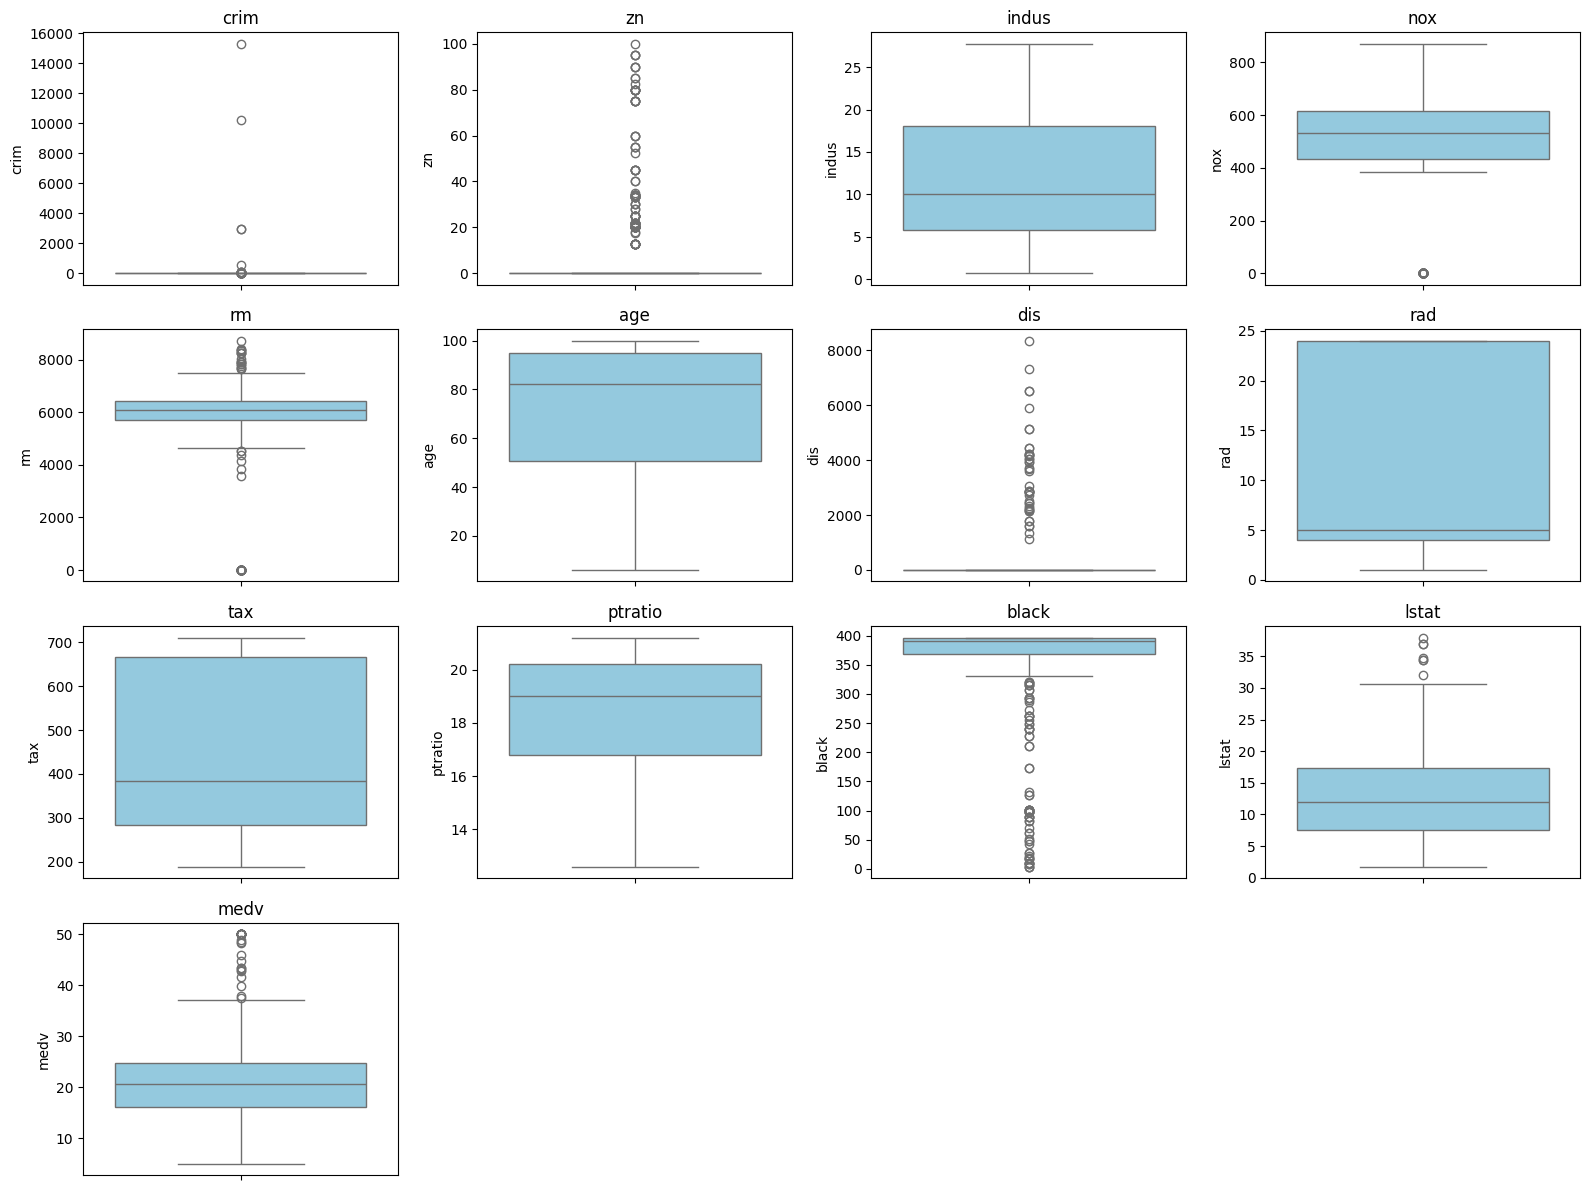

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(16, 3*n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
df.loc[df['rm'] > 1000, 'rm'] = df['rm'] / 1000

In [21]:
import numpy as np

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('medv')

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    df.loc[outliers_mask, col] = None

display(df.head())

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,NaN,2.31,0.0,538.0,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,469.0,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.03237,0.0,2.18,0.0,458.0,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0.0,458.0,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,NaN
4,0.08829,NaN,7.87,0.0,524.0,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9


In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df.select_dtypes(include=['float64', 'int64']))

df[df.select_dtypes(include=['float64', 'int64']).columns] = df_imputed

display(df.head())

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,0.0,2.31,0.0,538.0,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,469.0,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.03237,0.0,2.18,0.0,458.0,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0.0,458.0,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,NaN
4,0.08829,0.0,7.87,0.0,524.0,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9


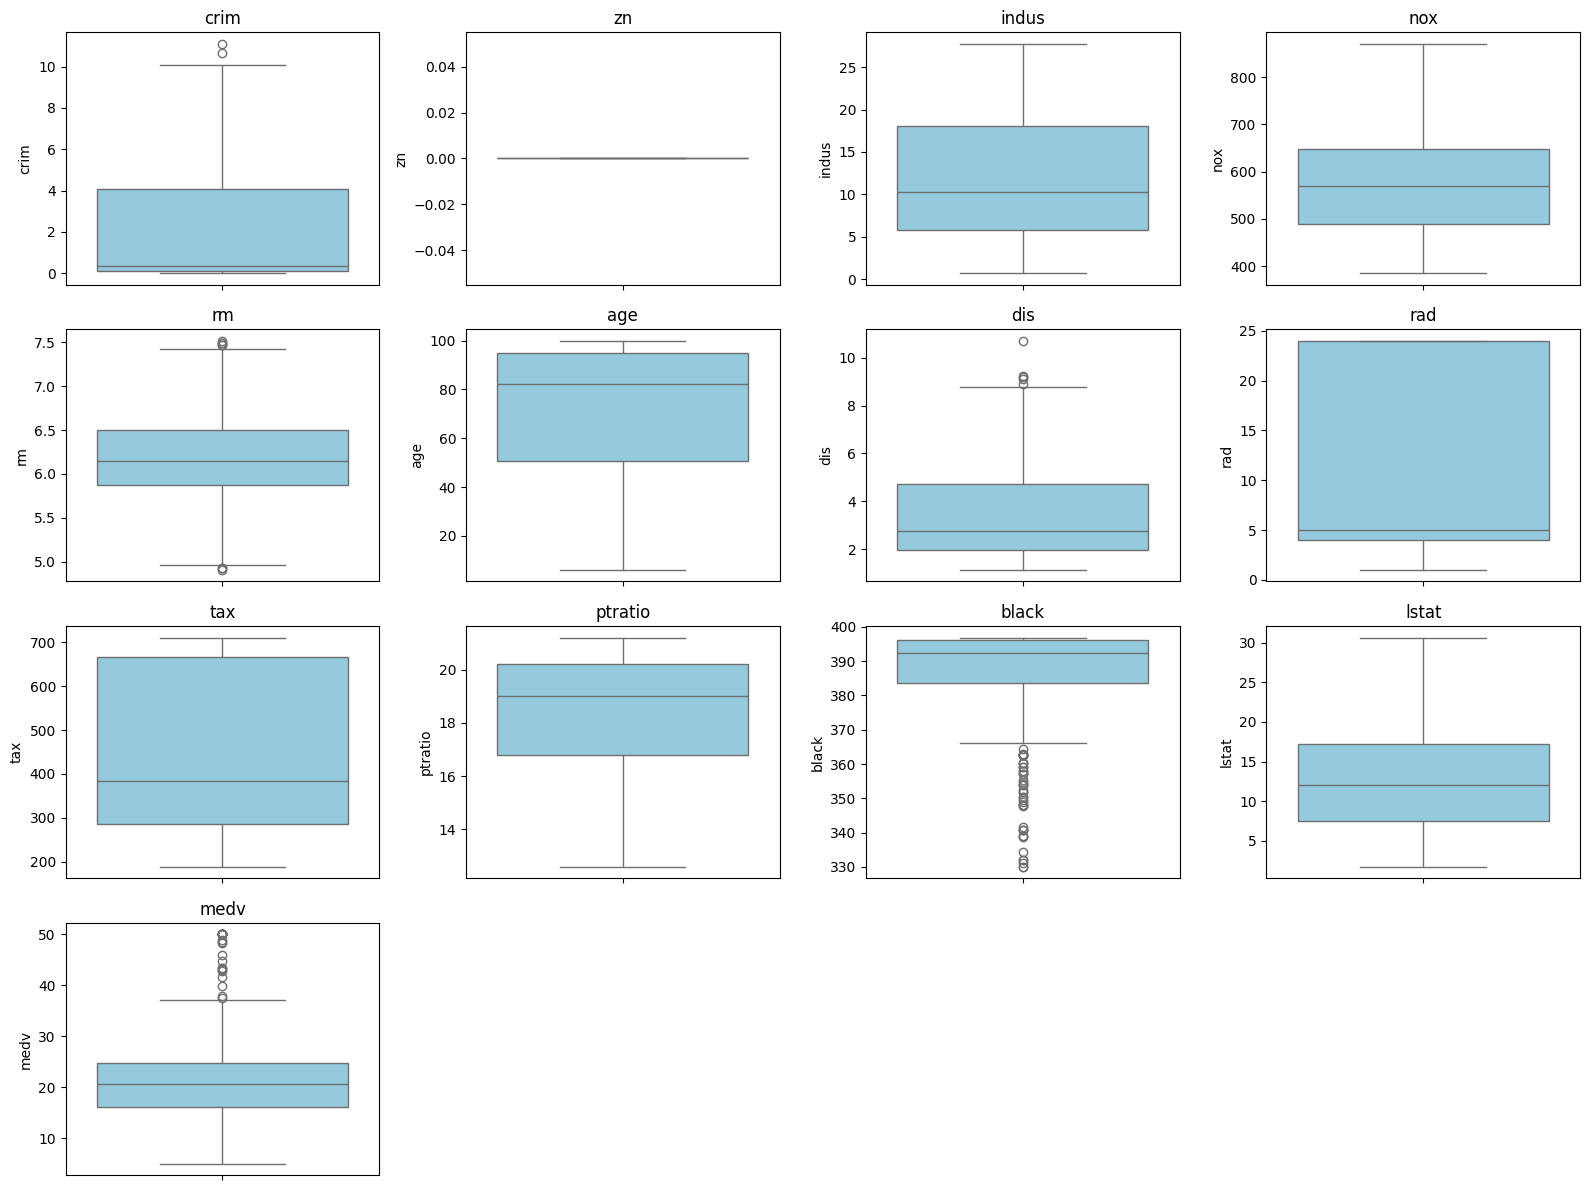

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(16, 3*n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Select the numerical columns to scale (excluding the target variable 'medv')
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('medv')

# Apply the scaler to the selected columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

display(df.head())

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,-0.716522,0.0,-1.385925,0.0,-0.294044,0.742071,-0.218002,0.316324,-1.002551,-0.720511,-1.386911,0.717027,-1.183160,24.0
1,-0.710107,0.0,-0.716283,0.0,-0.923954,0.441542,0.277307,0.781499,-0.888688,-1.036535,-0.268660,0.717027,-0.568023,21.6
2,-0.708561,0.0,-1.404213,0.0,-1.024374,1.567550,-0.919388,1.362291,-0.774826,-1.153581,0.133911,0.559676,-1.484814,33.4
3,-0.697350,0.0,-1.404213,0.0,-1.024374,1.858322,-0.615695,1.362291,-0.774826,-1.153581,0.133911,0.717027,-1.131406,NaN
4,-0.691469,0.0,-0.603738,0.0,-0.421851,-0.356616,-0.167386,1.096212,-0.547100,-0.632727,-1.431641,0.626914,-0.081532,22.9


In [25]:
import joblib

# Save the scaler
joblib.dump(scaler, '../scripts/models/precios_casas_boston/standard_scaler.pkl')

print("StandardScaler saved successfully.")

StandardScaler saved successfully.


In [26]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('medv', axis=1)
y = df['medv']

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (313, 13)
X_test shape: (135, 13)
y_train shape: (313,)
y_test shape: (135,)


In [27]:
from sklearn.impute import KNNImputer

# Impute missing values in X_train and X_test using a separate imputer
imputer_X = KNNImputer(n_neighbors=5)
X_train_imputed = imputer_X.fit_transform(X_train)
X_test_imputed = imputer_X.transform(X_test)

# Impute missing values in y_train using another imputer
imputer_y = KNNImputer(n_neighbors=5)
y_train_imputed = imputer_y.fit_transform(y_train.values.reshape(-1, 1))

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

# Define the MLP Regressor model
mlp_model = MLPRegressor(random_state=42, max_iter=1000)
# Initialize a dictionary to store the best models

# Define the parameter grid for MLP
param_grid_mlp = {
    'hidden_layer_sizes': [(50, 50), (100, 50)],
    'activation': ['tanh'],
    'solver': ['sgd'],
    'alpha': [0.01],
    'learning_rate': ['constant']
}

# Create the GridSearchCV object
grid_search_mlp = GridSearchCV(mlp_model, param_grid_mlp, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

# Fit the grid search to the data
# Use the imputed data for training
grid_search_mlp.fit(X_train_imputed, y_train_imputed.ravel()) # Use ravel() to convert y_train_imputed to 1D array

# Print the best parameters and best score
print("Best parameters for MLP:", grid_search_mlp.best_params_)
print("Best cross-validation MAPE for MLP:", -grid_search_mlp.best_score_)

# Store the best model
best_mlp_grid = grid_search_mlp.best_estimator_

# Make predictions on the test set with the best model
# Use the imputed test data for prediction
y_pred_mlp_grid = best_mlp_grid.predict(X_test_imputed)

# Calculate the MAPE for the best model on the test set
mape_mlp_grid = mean_absolute_percentage_error(y_test, y_pred_mlp_grid)

print(f"Test set MAPE for best MLP model: {mape_mlp_grid:.2f}")

Best parameters for MLP: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'solver': 'sgd'}
Best cross-validation MAPE for MLP: 0.12113305831983086


c:\Users\juans\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


ValueError: Input contains NaN.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Define the KNN Regressor model
knn_model = KNeighborsRegressor()

# Define an expanded parameter grid for KNN to get over 200 combinations
param_grid_knn_expanded = {
    'n_neighbors': [i for i in range(4, 12)],  # 14 different values
    'weights': ['distance'],        # 2 different values
    'metric': ['manhattan'], # 3 different values
    'p': [1, 2, 3, 4, 5, 6]                              # 6 different values for p (for minkowski metric)
}

# Create the GridSearchCV object
grid_search_knn_expanded = GridSearchCV(knn_model, param_grid_knn_expanded, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

# Fit the grid search to the data
grid_search_knn_expanded.fit(X_train_imputed, y_train_imputed.ravel())

# Print the best parameters and best score
print("Best parameters for KNN (expanded search):", grid_search_knn_expanded.best_params_)
print("Best cross-validation MAPE for KNN (expanded search):", -grid_search_knn_expanded.best_score_)

# Store the best model
best_knn_grid_expanded = grid_search_knn_expanded.best_estimator_

# Make predictions on the test set with the best model
y_pred_knn_grid_expanded = best_knn_grid_expanded.predict(X_test_imputed)

# Calculate the MAPE for the best model on the test set
mape_knn_grid_expanded = mean_absolute_percentage_error(y_test, y_pred_knn_grid_expanded)

print(f"Test set MAPE for best KNN model (expanded search): {mape_knn_grid_expanded:.2f}")


Best parameters for KNN (expanded search): {'metric': 'manhattan', 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}
Best cross-validation MAPE for KNN (expanded search): 0.09204945681136514
Test set MAPE for best KNN model (expanded search): 0.10


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

# Define the Decision Tree Regressor model
tree_model = DecisionTreeRegressor(random_state=42)

# Define an expanded parameter grid for Decision Tree to get over 200 combinations
param_grid_tree_expanded = {
    'max_depth': [None] + list(range(9, 17)),  # None and depths from 2 to 20 (1 + 19 = 20 values)
    'min_samples_split': [2, 3],  # 5 different values
    'min_samples_leaf': [1, 2, 3],       # 4 different values
    'criterion': ['squared_error'] # 4 different values
}


# Create the GridSearchCV object
grid_search_tree_expanded = GridSearchCV(tree_model, param_grid_tree_expanded, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

# Fit the grid search to the data
# Use the imputed data for training
grid_search_tree_expanded.fit(X_train_imputed, y_train_imputed.ravel())

# Print the best parameters and best score
print("Best parameters for Decision Tree (expanded search):", grid_search_tree_expanded.best_params_)
print("Best cross-validation MAPE for Decision Tree (expanded search):", -grid_search_tree_expanded.best_score_)

# Store the best model (Optional, as requested by the user to be removed)
best_tree_grid_expanded = grid_search_tree_expanded.best_estimator_

# Make predictions on the test set with the best model
# Use the imputed test data for prediction
y_pred_tree_grid_expanded = best_tree_grid_expanded.predict(X_test_imputed)

# Calculate the MAPE for the best model on the test set
mape_tree_grid_expanded = mean_absolute_percentage_error(y_test, y_pred_tree_grid_expanded)

print(f"Test set MAPE for best Decision Tree model (expanded search): {mape_tree_grid_expanded:.2f}")

Best parameters for Decision Tree (expanded search): {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation MAPE for Decision Tree (expanded search): 0.11037290885616599
Test set MAPE for best Decision Tree model (expanded search): 0.10


In [ ]:
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# Define the Bayesian Ridge Regressor model
bayesian_ridge_model = BayesianRidge()

# Define an expanded parameter grid for Bayesian Ridge
param_grid_bayesian_ridge_expanded = {
    'alpha_1': np.logspace(-7, -5, 10), # 10 values
    'alpha_2': np.logspace(-7, -5, 10), # 10 values
    'lambda_1': np.logspace(-7, -5, 10), # 10 values
    'lambda_2': np.logspace(-7, -5, 10), # 10 values
}

# Create the GridSearchCV object
grid_search_bayesian_ridge_expanded = GridSearchCV(bayesian_ridge_model, param_grid_bayesian_ridge_expanded, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

# Fit the grid search to the data
# Use the imputed data for training
grid_search_bayesian_ridge_expanded.fit(X_train_imputed, y_train_imputed.ravel())

# Print the best parameters and best score
print("Best parameters for Bayesian Ridge (expanded search):", grid_search_bayesian_ridge_expanded.best_params_)
print("Best cross-validation MAPE for Bayesian Ridge (expanded search):", -grid_search_bayesian_ridge_expanded.best_score_)

# Store the best model
best_bayesian_ridge_grid_expanded = grid_search_bayesian_ridge_expanded.best_estimator_

# Make predictions on the test set with the best model
# Use the imputed test data for prediction
y_pred_bayesian_ridge_grid_expanded = best_bayesian_ridge_grid_expanded.predict(X_test_imputed)

# Calculate the MAPE for the best model on the test set
mape_bayesian_ridge_grid_expanded = mean_absolute_percentage_error(y_test, y_pred_bayesian_ridge_grid_expanded)

print(f"Test set MAPE for best Bayesian Ridge model (expanded search): {mape_bayesian_ridge_grid_expanded:.2f}")

Best parameters for Bayesian Ridge (expanded search): {'alpha_1': np.float64(1e-05), 'alpha_2': np.float64(1e-07), 'lambda_1': np.float64(1e-07), 'lambda_2': np.float64(1e-05)}
Best cross-validation MAPE for Bayesian Ridge (expanded search): 0.15518727274963207
Test set MAPE for best Bayesian Ridge model (expanded search): 0.14


In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

# Define the Bagging Regressor model
bagging_model = BaggingRegressor(random_state=42)

# Define an expanded parameter grid for Bagging Regressor
param_grid_bagging_expanded = {
    'n_estimators': [9,10,11],  # Number of base estimators
    'max_samples': [1.0],      # The number of samples to draw from X
    'max_features': [ 1.0],     # The number of features to draw from X
    'bootstrap': [False],               # Whether samples are drawn with replacement
    'bootstrap_features': [True]       # Whether features are drawn with replacement
}



# Create the GridSearchCV object
grid_search_bagging_expanded = GridSearchCV(bagging_model, param_grid_bagging_expanded, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

# Fit the grid search to the data
# Use the imputed data for training
grid_search_bagging_expanded.fit(X_train_imputed, y_train_imputed.ravel())

# Print the best parameters and best score
print("Best parameters for Bagging Regressor (expanded search):", grid_search_bagging_expanded.best_params_)
print("Best cross-validation MAPE for Bagging Regressor (expanded search):", -grid_search_bagging_expanded.best_score_)

# Store the best model
best_bagging_grid_expanded = grid_search_bagging_expanded.best_estimator_

# Make predictions on the test set with the best model
# Use the imputed test data for prediction
y_pred_bagging_grid_expanded = best_bagging_grid_expanded.predict(X_test_imputed)

# Calculate the MAPE for the best model on the test set
mape_bagging_grid_expanded = mean_absolute_percentage_error(y_test, y_pred_bagging_grid_expanded)

print(f"Test set MAPE for best Bagging Regressor model (expanded search): {mape_bagging_grid_expanded:.2f}")


Best parameters for Bagging Regressor (expanded search): {'bootstrap': False, 'bootstrap_features': True, 'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 11}
Best cross-validation MAPE for Bagging Regressor (expanded search): 0.09027616517173553
Test set MAPE for best Bagging Regressor model (expanded search): 0.09


In [ ]:
import joblib

# Save the best Bagging Regressor model
joblib.dump(best_bagging_grid_expanded, '../scripts/models/precios_casas_boston/br_model.pkl')

print("Best Bagging Regressor model saved successfully.")

Best Bagging Regressor model saved successfully.
